![](https://github.com/mccode-dev/PaNRAID/raw/main/images/toplogo-diadem.png)

# From a McStas instrument to a simulation dataset ready for AI

Let's think together on what is needed for the generation of a large dataset of simulation for AI purposes using **McStas**. We will need to have several aspects into consideration, amongst them: 

- **purpose**: from an AI point of view, supervised or unsupervised? Any objective in particular? 

- **structure**: data, metadata specification, labels, targets, etc.

- **parameter space**: what to vary and how. 

- **Format**: NeXus, HDF5, csv, etc.  May be related to posterior usage.

Many of the considerations that we will work on and the example we are using is based on [the following paper: "Learning from virtual experiments to assist users of Small Angle Neutron Scattering in model selection" Robledo et al. 2024](https://www.nature.com/articles/s41598-024-65712-y)

In [ ]:
from pathlib import Path
import itertools
import json
import math
import shlex
import shutil
import subprocess

import h5py
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import qmc

ROOT = Path.cwd()
print(f'Working directory: {ROOT}')
print(f'mcrun available: {shutil.which("mcrun") is not None}')

## Introduction

In this tutorial, we will generate a large dataset of Small Angle Neutron Scattering (SANS) virtual experiments at the [KWS-1 beamline](https://mlz-garching.de/kws-1) of the FRM-II reactor in Graching, Germany. 

For this, we will work with three different samples from the [SAS models available in McStas](https://www.mcstas.org/download/components/3.8.4/#sasmodels) as an introductory example:

- spheres: [McStas component documentation](https://www.mcstas.org/download/components/3.8.4/sasmodels/SasView_sphere.html) - [SasView documentation](https://www.sasview.org/docs/user/models/sphere.html)

<img src="https://sastutorials.org/Spheres/Spheres.png" height=100 />


- core-shells: [McStas component documentation](https://www.mcstas.org/download/components/3.8.4/sasmodels/SasView_core_shell_sphere.html) - [SASview documentation](https://www.sasview.org/docs/user/models/core_shell_sphere.html)

<img src="https://sastutorials.org/CoreShell/CoreShell.png" width=100 />


- linear pearls: [McStas component documentation](https://www.mcstas.org/download/components/3.8.4/sasmodels/SasView_linear_pearls.html) - [SasView documentation](https://www.sasview.org/docs/user/models/linear_pearls.html)

<img src="https://www.sasview.org/docs/_images/linear_pearls_geometry.jpg" height=100 />

The idea is that we can change the samples measured at the KWS-2 beamline, but we can also modify the instrument parameters of the beamline for each sample.



## Define the scientific learning problem first

Let's say we focus on trying to classify a scattering pattern measured at KWS1 between the three SAS models defined. 

A simulation parameter can play one of several roles

| Role | KWS example | Typical ML treatment |
|---|---|---|
| Instrument configuration | wavelength, slit setting, detector distance | input metadata or nuisance variation |
| Sample model | sphere, core–shell, linear pearls | class label |
| Sample parameter | radius, shell thickness, polydispersity | regression target or nuisance variation |
| Monte Carlo setting | neutron histories, random seed | fidelity/noise control; usually not a target |

Write the intended model input and output before launching a large sweep. For example: *infer sample family and particle radius from a 2D detector image, robustly across wavelength and collimation settings*.

In [2]:
sample_instruments = [
    ROOT / 'kws_sphere.instr',
    ROOT / 'kws_core_shell.instr',
    ROOT / 'kws_linear_pearls.instr',
]
print('Sample instrument definitions used in this lesson:')
for path in sample_instruments:
    print(f' - {path.name}: {"found" if path.exists() else "missing"}')

# The DEFINE INSTRUMENT declaration contains the parameters that mcrun may vary.
print('\nBeginning of each instrument definition:')
for path in sample_instruments:
    declaration = '\n'.join(path.read_text().splitlines()[:12])
    print(f'\n--- {path.name} ---\n{declaration}')

Sample instrument definitions used in this lesson:
 - kws_sphere.instr: found
 - kws_core_shell.instr: found
 - kws_linear_pearls.instr: found

Beginning of each instrument definition:

--- kws_sphere.instr ---
DEFINE INSTRUMENT KWS1_sphere(Lam=4.5,
                      InstSetting=1, // 1. 8-1.2; 2. 8-8; 3. 20-20; 4. 4-4
                      SlitSetting=1, // 1. wide thin; 2. Wide larg; 3. narrow thinnest.
                      vheight=0.0, // height of slit before the detector and detector position
                      hwidth=0.0, // width of the slit before the detector and detector position
                      zdepth=0.001, // sampleholder thickness 0.001 or 0.002

                      // model parameters
                      sld=1, sld_solvent=6, radius=50, pd_radius=0.0, 
                      model_abs=0.0
                      )


--- kws_core_shell.instr ---
DEFINE INSTRUMENT KWS1_core_shell(Lam=4.5,
                      InstSetting=1, // 1. 8-1.2; 2. 8-8; 3. 20-20; 4.

### Constructing a balanced simulation design

Begin with the `DEFINE INSTRUMENT` declaration in each `.instr` file. It tells us which values can be supplied at run time. For example, the sphere instrument exposes `radius` and `pd_radius`; the core–shell instrument additionally exposes `thickness`; and the linear-pearls instrument exposes `edge_sep`.

The dataset is intended for classification among the three sample form factors, we will store the class label in `sample_family`. 

A dataset design is assembled from four decisions:

- **Instrument:** the `.instr` file to simulate.
- **Fidelity:** `-n` gives the neutron histories in every simulation.
- **Execution and output:** `--mpi` selects MPI ranks and `--format=NeXus` requests HDF5/NeXus output.
- **Parameter design:** one manifest row specifies the parameters and output directory for one simulation.

Now comes in very tricky questions. Which parameters should I vary? How should I vary the parameters? What distribution should I define for each parameter?

Cartesian sweeps are possible with the `mcrun` command using its `--list` and `--multi` options.

> Check `mcrun --help` for the installed McStas version. Scheduler and MPI options vary across systems.

```bash
    -L, --list          Use a fixed list of points for scanning, walking every
                        scanned parameter's list together in lockstep (all
                        lists must then be the same length). Combine with
                        -M/--multi instead to take the cartesian product of
                        each parameter's own list (lists may then have
                        different lengths).
    -M, --multi         Run a multi-dimensional scan (the cartesian product of
                        every scanned parameter's own points, rather than
                        walking them all in lockstep). Combine with -L/--list
                        (each parameter's explicit list can then have a
                        different length) or give -N a comma-separated list
                        (see -N/--numpoints) for per-parameter point counts.
```

#### Sphere example: a 10-point Cartesian sweep in one NeXus file

Here, `-L` defines five explicit radii and two explicit radius-polydispersity values. Adding `-M` asks `mcrun` for their Cartesian product, so it runs $5 \times 2 = 10$ simulations. With `--format=NeXus`, the scan is stored as ten `NXentry` groups (`entry1`, ..., `entry10`) in the single file `cartesian_sphere_sweep/mccode.h5`. Each entry contains its parameter values and monitor data.

The equivalent terminal command is:

```bash
mcrun kws_sphere.instr -M -L radius=20,35,50,65,80 pd_radius=0.0,0.1 -n 100000 --format=NeXus -d cartesian_sphere_sweep
```

> This requires a recent McStas version whose `mcrun --help` lists `-L` and `-M`. Delete or rename the output directory before rerunning if your McStas installation does not overwrite existing output.


In [ ]:
sweep_dir = ROOT / 'cartesian_sphere_sweep'
sweep_file = sweep_dir / 'mccode.h5'
sweep_command = [
    'mcrun', 'kws_sphere.instr',
    '-M', '-L',
    'radius=20,35,50,65,80',
    'pd_radius=0.0,0.1',
    '-n', '100000',
    '--format=NeXus',
    '-d', str(sweep_dir),
]

print('Running:', shlex.join(sweep_command))
if sweep_file.exists():
    print(f'Using existing output: {sweep_file}')
elif shutil.which('mcrun') is None:
    raise RuntimeError('mcrun is not available; run the command above in a McStas-configured terminal')
else:
    subprocess.run(sweep_command, cwd=ROOT, check=True)
    print(f'Created: {sweep_file}')


#### Open and explore the NeXus scan

A NeXus file is an HDF5 file with a standardized hierarchy, so it can be opened directly with `h5py.File`. The top-level `entry*` groups are the ten simulations. Within each entry, `simulation/Param` records the inputs and `data` contains one group per monitor. `visititems` is a useful first inspection tool because it prints every group and dataset without requiring prior knowledge of the hierarchy. GUI alternatives include HDFView and NeXpy.


In [58]:
with h5py.File(sweep_file, 'r') as nexus:
    entries = [name for name in nexus if name.startswith('entry')]
    print(f'{len(entries)} simulations: {entries} \n')
    print('Contents of the first entry:')
    nexus[entries[0]].visititems(
        lambda name, obj: print(f'{name:60s} {obj.shape} {obj.dtype}')
        if isinstance(obj, h5py.Dataset) else None
    )

10 simulations: ['entry1', 'entry10', 'entry2', 'entry3', 'entry4', 'entry5', 'entry6', 'entry7', 'entry8', 'entry9'] 

Contents of the first entry:
data/PSD_scattering_psd/X_position__cm_                      (144,) float64
data/PSD_scattering_psd/Y_position__cm_                      (256,) float64
data/PSD_scattering_psd/data                                 (144, 256) float64
data/PSD_scattering_psd/errors                               (144, 256) float64
data/PSD_scattering_psd/ncount                               (144, 256) float64
data/PSDr_av_dat/Radius__m_                                  (300,) float64
data/PSDr_av_dat/data                                        (300,) float64
data/PSDr_av_dat/errors                                      (300,) float64
data/PSDr_av_dat/ncount                                      (300,) float64
data/PSDr_dat/Radius__m_                                     (300,) float64
data/PSDr_dat/data                                           (300,) float64
dat

entry1: radius=  20, pd_radius=0.0, image=(144, 256)
entry2: radius=  35, pd_radius=0.0, image=(144, 256)
entry3: radius=  50, pd_radius=0.0, image=(144, 256)
entry4: radius=  65, pd_radius=0.0, image=(144, 256)
entry5: radius=  80, pd_radius=0.0, image=(144, 256)
entry6: radius=  20, pd_radius=0.1, image=(144, 256)
entry7: radius=  35, pd_radius=0.1, image=(144, 256)
entry8: radius=  50, pd_radius=0.1, image=(144, 256)
entry9: radius=  65, pd_radius=0.1, image=(144, 256)
entry10: radius=  80, pd_radius=0.1, image=(144, 256)


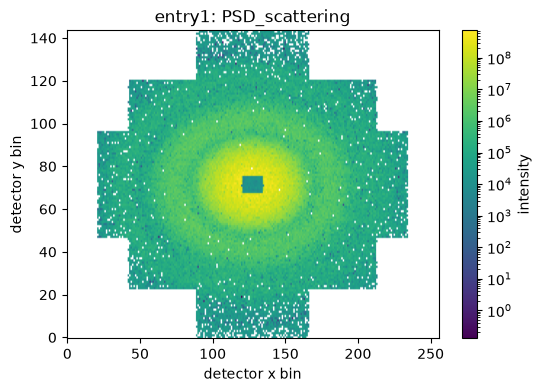

In [67]:
# Read the scanned parameters and one detector image from every simulation.
with h5py.File(sweep_file, 'r') as nexus:
    entries = sorted(
        (name for name in nexus if name.startswith('entry')),
        key=lambda name: int(name.removeprefix('entry')),
    )
    for entry_name in entries:
        entry = nexus[entry_name]

        radius = float(entry["simulation/Param/radius"].asstr()[0])
        pd_radius = float(entry["simulation/Param/pd_radius"].asstr()[0])
        image = entry["data/PSD_scattering_psd/data"][()]
        print(f'{entry_name}: radius={radius:4.0f}, pd_radius={pd_radius:.1f}, image={image.shape}')

    plot_image = nexus["entry1/data/PSD_scattering_psd/data"][()]

plt.figure(figsize=(6, 4))
plt.imshow(plot_image, origin='lower', aspect='auto', norm='log')
plt.colorbar(label='intensity')
plt.title(f'{entries[0]}: PSD_scattering')
plt.xlabel('detector x bin')
plt.ylabel('detector y bin')
plt.show()


## Beyond cartesian sweep

The small sphere-only example below demonstrates a Cartesian sweep. We will not use Cartesian sweeps for the full three-class production dataset because classes with different numbers of parameters would produce different numbers of simulations, and we want to keep that dataset balanced.

We will choose the total number of simulations we want in the database `N_SIMULATIONS`, and then it will be divided as evenly as mathematically possible among the three classes. When `N` is not divisible by three, the first classes receive one extra row, so class counts differ by at most one. The parameter bounds below are teaching choices and should be justified scientifically for a real dataset.

In [3]:
# Total dataset size. Change this one value to scale the production design.
N_SIMULATIONS = 1_000
RANDOM_SEED = 42
histories = 10_000_000

# Compile each instrument once, then run its binary for every manifest row.
# Use 'mpi' by default; change to 'openacc' for an NVIDIA GPU build, or 'serial'.
BACKEND = 'mpi'
MPI_RANKS = 6
if BACKEND not in {'mpi', 'openacc', 'serial'}:
    raise ValueError("BACKEND must be 'mpi', 'openacc', or 'serial'")

class_specs = {
    'sphere': {
        'instrument': 'kws_sphere.instr',
        'ranges': {'radius': (10, 100), 'pd_radius': (0.0, 0.1)},
    },
    'core_shell': {
        'instrument': 'kws_core_shell.instr',
        'ranges': {'thickness': (10, 100), 'radius': (10, 100), 'pd_radius': (0.0, 0.1)},
    },
    'linear_pearls': {
        'instrument': 'kws_linear_pearls.instr',
        'ranges': {'radius': (10, 100), 'edge_sep': (100, 400), 'pd_radius': (0.0, 0.1)},
    },
}

def balanced_class_counts(total, class_names):
    if not isinstance(total, (int, np.integer)) or total < 1:
        raise ValueError('N_SIMULATIONS must be a positive integer')
    base, remainder = divmod(int(total), len(class_names))
    return {name: base + (index < remainder) for index, name in enumerate(class_names)}

class_counts = balanced_class_counts(N_SIMULATIONS, list(class_specs))
for name, count in class_counts.items():
    print(f'{name:14s}: {count:4d} simulations')
print(f'Total: {sum(class_counts.values()):,} simulations and {N_SIMULATIONS * histories:,} neutron histories')

sphere        :  334 simulations
core_shell    :  333 simulations
linear_pearls :  333 simulations
Total: 1,000 simulations and 10,000,000,000 neutron histories


## Design the parameter space

A Cartesian grid is transparent but scales exponentially and introduces strong correlations between neighboring points. Random, Latin-hypercube, or low-discrepancy designs cover higher-dimensional spaces more efficiently. Distributions should reflect scientific use: log-uniform sampling is often preferable for positive parameters spanning orders of magnitude.

Always include physically valid bounds and constraints (for example, shell thickness must be positive). Reserve boundary and out-of-distribution regions deliberately for evaluation.

In [71]:
# A small, explicit cartesian grid
debug_space = {
    'radius': [10.0, 55.0, 100.0],
    'pd_radius': [0.0, 0.05, 0.1, 0.2],
}
debug_design = []

for radius in debug_space["radius"]:
    for pd_radius in debug_space["pd_radius"]:
        debug_design.append({
            "radius": radius,
            "pd_radius": pd_radius,
        })
        
print(f'{len(debug_design)} design points')
debug_design

12 design points


[{'radius': 10.0, 'pd_radius': 0.0},
 {'radius': 10.0, 'pd_radius': 0.05},
 {'radius': 10.0, 'pd_radius': 0.1},
 {'radius': 10.0, 'pd_radius': 0.2},
 {'radius': 55.0, 'pd_radius': 0.0},
 {'radius': 55.0, 'pd_radius': 0.05},
 {'radius': 55.0, 'pd_radius': 0.1},
 {'radius': 55.0, 'pd_radius': 0.2},
 {'radius': 100.0, 'pd_radius': 0.0},
 {'radius': 100.0, 'pd_radius': 0.05},
 {'radius': 100.0, 'pd_radius': 0.1},
 {'radius': 100.0, 'pd_radius': 0.2}]

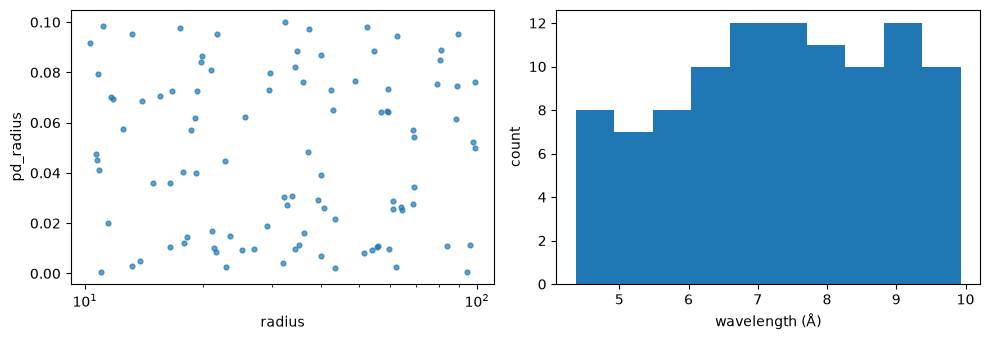

In [77]:
# A randomized design
rng = np.random.default_rng(20260912)
n_design = 100
random_design = {
    'radius': np.exp(rng.uniform(np.log(10.0), np.log(100.0), n_design)),
    'pd_radius': rng.uniform(0.0, 0.1, n_design),
    'Lam': rng.uniform(4.0, 10.0, n_design),  # example instrument variation
}
fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
axes[0].scatter(random_design['radius'], random_design['pd_radius'], s=12, alpha=.7)
axes[0].set(xlabel='radius', ylabel='pd_radius', xscale='log')
axes[1].hist(random_design['Lam'], bins=10)
axes[1].set(xlabel='wavelength (Å)', ylabel='count')
plt.tight_layout()

### Comparison with Latin-hypercube sampling

Independent random sampling can leave gaps and clusters. Latin-hypercube sampling divides every parameter's probability range into equally probable intervals and uses each interval once. This improves one-dimensional coverage without constructing an exponentially large Cartesian grid.

Latin-hypercube sampling is provided by SciPy's `scipy.stats.qmc` module. Scikit-learn provides random parameter sampling for model search, but it does not provide a general Latin-hypercube design generator. `qmc.LatinHypercube` creates points in the unit cube and `qmc.scale` maps them to physical bounds.

In [78]:
parameter_names = ['radius', 'pd_radius', 'Lam']
lower_bounds = [10.0, 0.0, 4.0]
upper_bounds = [100.0, 0.1, 10.0]

lhs_sampler = qmc.LatinHypercube(d=len(parameter_names), seed=20260912)
lhs_unit = lhs_sampler.random(n=n_design)
lhs_scaled = qmc.scale(lhs_unit, lower_bounds, upper_bounds)
lhs_design = [dict(zip(parameter_names, row)) for row in lhs_scaled]

print(f'Generated {len(lhs_design)} Latin-hypercube points')
lhs_design[:3]

Generated 100 Latin-hypercube points


[{'radius': np.float64(51.20131713370999),
  'pd_radius': np.float64(0.023076588759343108),
  'Lam': np.float64(4.923870365922367)},
 {'radius': np.float64(95.51615973437899),
  'pd_radius': np.float64(0.013957963758165687),
  'Lam': np.float64(9.758389391020138)},
 {'radius': np.float64(91.87155284106213),
  'pd_radius': np.float64(0.020397393233479593),
  'Lam': np.float64(9.19184262190802)}]

Centered discrepancy; lower indicates more even unit-cube coverage:
  independent random: 0.04945
  Latin hypercube:    0.00073


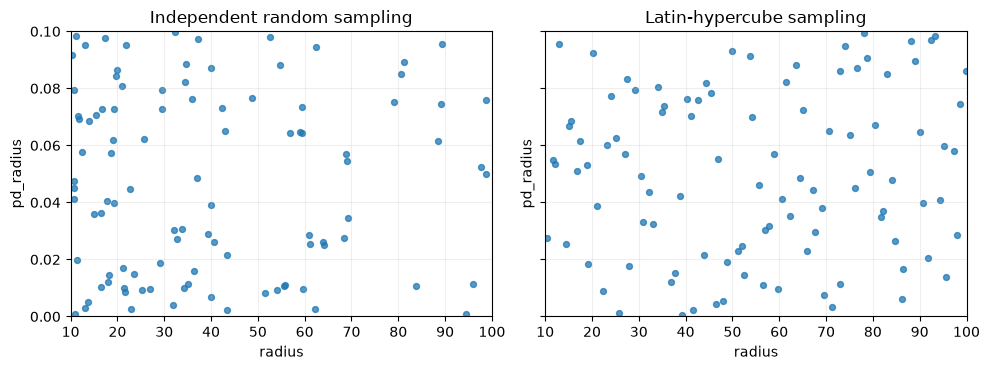

In [79]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.8), sharex=True, sharey=True)
axes[0].scatter(random_design['radius'], random_design['pd_radius'], s=18, alpha=.75)
axes[0].set_title('Independent random sampling')
axes[1].scatter([row['radius'] for row in lhs_design],
                [row['pd_radius'] for row in lhs_design], s=18, alpha=.75)
axes[1].set_title('Latin-hypercube sampling')
for ax in axes:
    ax.set(xlabel='radius', ylabel='pd_radius', xlim=(10, 100), ylim=(0, 0.1))
    ax.grid(alpha=.2)
plt.tight_layout()

random_unit = np.column_stack([
    (random_design['radius'] - 10.0) / 90.0,
    random_design['pd_radius'] / 0.1,
    (random_design['Lam'] - 4.0) / 6.0,
])
print('Centered discrepancy; lower indicates more even unit-cube coverage:')
print(f'  independent random: {qmc.discrepancy(random_unit):.5f}')
print(f'  Latin hypercube:    {qmc.discrepancy(lhs_unit):.5f}')

Now we can create a manifest that contains the metadata that will be useful at a later stage, for quick and easy inspection of the parameters used.

In [ ]:
# Latin-hypercube sampling gives each class good coverage of its own parameter space.
# https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.qmc.LatinHypercube.html
design = []
for class_index, (family, spec) in enumerate(class_specs.items()):
    parameter_names = list(spec['ranges'])
    bounds = np.asarray([spec['ranges'][name] for name in parameter_names], dtype=float)
    sampler = qmc.LatinHypercube(d=len(parameter_names), seed=RANDOM_SEED + class_index)
    values = qmc.scale(sampler.random(class_counts[family]), bounds[:, 0], bounds[:, 1])
    for index, parameter_values in enumerate(values):
        design.append({
            'simulation_id': f'{family}_{index:06d}',
            'sample_family': family,
            'instrument': spec['instrument'],
            **dict(zip(parameter_names, map(float, parameter_values))),
        })

assert len(design) == N_SIMULATIONS
assert max(class_counts.values()) - min(class_counts.values()) <= 1
print(f'Created a balanced manifest with {len(design):,} rows: {class_counts}')
design[:3]

Created a balanced manifest with 1,000 rows: {'sphere': 334, 'core_shell': 333, 'linear_pearls': 333}


[{'simulation_id': 'sphere_000000',
  'sample_family': 'sphere',
  'instrument': 'kws_sphere.instr',
  'radius': 22.99504178332324,
  'pd_radius': 0.05136560525755927},
 {'simulation_id': 'sphere_000001',
  'sample_family': 'sphere',
  'instrument': 'kws_sphere.instr',
  'radius': 28.900377806011903,
  'pd_radius': 0.028533722146988218},
 {'simulation_id': 'sphere_000002',
  'sample_family': 'sphere',
  'instrument': 'kws_sphere.instr',
  'radius': 62.78899412781471,
  'pd_radius': 0.05389951426597703}]

## Generate one command per manifest row

The function below converts a manifest row into an argument list suitable for `subprocess.run`. This guarantees that the commands execute exactly the balanced design above instead of expanding class-dependent Cartesian products. Argument lists are safer than manually concatenated shell commands because quoting is unambiguous. Each simulation receives its own stable output directory.

The textual command printed with `shlex.join` is the same command that will later be placed in a shell script.

In [20]:
def instrument_executable(instrument):
    return f'./{Path(instrument).stem}.out'

def make_compile_command(instrument, backend=BACKEND, mpi=MPI_RANKS):
    command = ['mcrun', '-c', '-n0', '--format=NeXus',]
    if backend == 'mpi':
        if mpi < 1:
            raise ValueError('mpi must be positive')
        command.append(f'--mpi={int(mpi)}')
    elif backend == 'openacc':
        command.append('--openacc')
    elif backend != 'serial':
        raise ValueError(f'Unknown backend: {backend}')
    command.append(Path(instrument).name)
    return command

def make_simulation_command(
    row, histories=10_000_000, backend=BACKEND, mpi=MPI_RANKS,
    output_root='generated_dataset',
):
    instrument = ROOT / row['instrument']
    if not instrument.is_file():
        raise FileNotFoundError(instrument)
    if histories < 1:
        raise ValueError('histories must be positive')
    source = instrument.read_text()
    spec = class_specs[row['sample_family']]
    for parameter, (low, high) in spec['ranges'].items():
        if parameter not in source:
            raise ValueError(f'{parameter!r} was not found in {instrument.name}')
        if not low <= row[parameter] <= high:
            raise ValueError(f'{parameter}={row[parameter]} is outside [{low}, {high}]')
    executable_command = [
        instrument_executable(instrument.name),
        f'--ncount={int(histories)}',
        f'--dir={output_root}/{row["simulation_id"]}',
        '--format=NeXus',
        '--bufsiz=10000000',
    ]
    executable_command.extend(f'{name}={row[name]:.12g}' for name in spec['ranges'])
    if backend == 'mpi':
        if mpi < 1:
            raise ValueError('mpi must be positive')
        return ['mpirun', '-np', str(int(mpi)), *executable_command]
    if backend in {'openacc', 'serial'}:
        return executable_command
    raise ValueError(f'Unknown backend: {backend}')

simulation_commands = [
    make_simulation_command(row, histories=histories, backend=BACKEND, mpi=MPI_RANKS)
    for row in design
]
print(f'Generated {len(simulation_commands):,} commands')
for row, command in list(zip(design, simulation_commands))[:3]:
    print(f'{row["simulation_id"]}:\n  {shlex.join(command)}\n')

Generated 1,000 commands
sphere_000000:
  mpirun -np 6 ./kws_sphere.out --ncount=10000000 --dir=generated_dataset/sphere_000000 --format=NeXus --bufsiz=10000000 radius=22.9950417833 pd_radius=0.0513656052576

sphere_000001:
  mpirun -np 6 ./kws_sphere.out --ncount=10000000 --dir=generated_dataset/sphere_000001 --format=NeXus --bufsiz=10000000 radius=28.900377806 pd_radius=0.028533722147

sphere_000002:
  mpirun -np 6 ./kws_sphere.out --ncount=10000000 --dir=generated_dataset/sphere_000002 --format=NeXus --bufsiz=10000000 radius=62.7889941278 pd_radius=0.053899514266



In [50]:
SLURM_HEADER = '''#!/bin/bash
#SBATCH --job-name=generate_dataset_%j
#SBATCH --error=generate_dataset_%j.err
#SBATCH --output=generate_dataset_%j.out
#SBATCH --nodes 1
#SBATCH --partition=mesonet
#SBATCH --gres=gpu:1
#SBATCH --ntasks=1
#SBATCH --time 02:00:00
#SBATCH --account m26216
'''

def shell_script(family, commands):
    instrument = class_specs[family]['instrument']
    compile_command = make_compile_command(instrument, backend=BACKEND, mpi=MPI_RANKS)
    lines = [
        SLURM_HEADER.rstrip(),
        'set -euo pipefail',
        '',
        '# Generated from the balanced manifest in this notebook.',
        '# Compile the instrument once; simulations below call the binary directly.',
        'mkdir -p generated_dataset',
        shlex.join(compile_command),
        '',
    ]
    lines.extend(shlex.join(command) for command in commands)
    return '\n'.join(lines) + '\n'

generated_scripts = {}
for family in class_specs:
    commands = [command for row, command in zip(design, simulation_commands) if row['sample_family'] == family]
    generated_scripts[f'run_generated_{family}.sh'] = shell_script(family, commands)

for family in class_specs:
    filename = f'run_generated_{family}.sh'
    print(f'{filename}: {class_counts[family]} simulation commands')

run_generated_sphere.sh: 334 simulation commands
run_generated_core_shell.sh: 333 simulation commands
run_generated_linear_pearls.sh: 333 simulation commands


### Write one `.sh` file per sample instrument

Each generated script starts with the cluster's Slurm header and `set -euo pipefail`, which stops on a failed command, an unset variable, or a failed command within a pipeline. It compiles its sample instrument exactly once with the selected `BACKEND`, then invokes the compiled binary for every manifest row. `BACKEND='mpi'` is the default; change it to `'openacc'` for an NVIDIA GPU build. Calling the binary directly prevents `mcrun` from copying identical instrument and generated-C files into every simulation directory.

The cell below is opt-in because it creates files. When enabled, it writes:

- `run_generated_sphere.sh`;
- `run_generated_core_shell.sh`;
- `run_generated_linear_pearls.sh`.

It also writes `simulation_manifest.json`, the definitive ordered record of all `N_SIMULATIONS` labels and parameter combinations, and adds executable permission to the scripts. A script can then be started from a McStas-configured terminal with, for example, `./run_generated_sphere.sh`. Existing files are not overwritten unless `OVERWRITE_SCRIPTS` is also enabled. Before a production run, first reduce `histories` or `N_SIMULATIONS` for a smoke test and inspect the NeXus output.

In [ ]:
WRITE_SCRIPTS = True
OVERWRITE_SCRIPTS = True

if WRITE_SCRIPTS:
    manifest_path = ROOT / 'simulation_manifest.json'
    if manifest_path.exists() and not OVERWRITE_SCRIPTS:
        print(f'Skipped existing {manifest_path.name}')
    else:
        manifest_path.write_text(json.dumps(design, indent=2) + '\n')
        print(f'Wrote {manifest_path.name} with {len(design):,} rows')
    for filename, content in generated_scripts.items():
        destination = ROOT / filename
        if destination.exists() and not OVERWRITE_SCRIPTS:
            print(f'Skipped existing {destination.name}')
            continue
        destination.write_text(content)
        destination.chmod(destination.stat().st_mode | 0o111)
        print(f'Wrote executable {destination.name}')
else:
    print('Dry run only. Set WRITE_SCRIPTS=True to create the three shell scripts.')

Skipped existing simulation_manifest.json
Wrote executable run_generated_sphere.sh
Wrote executable run_generated_core_shell.sh
Wrote executable run_generated_linear_pearls.sh


### Run a small smoke test directly from Python

The same compile-once and binary-run command builders launch a test without a shell script. This cell creates the `smoke_test` parent directory, removes only the disposable output for this simulation ID when rerun, compiles for the selected backend, and launches one small run. Set `RUN_SMOKE_TEST=False` for a dry run. Avoid testing the full production specification first: compilation or parameter errors should be discovered cheaply.

In [ ]:
smoke_row = design[0]
SMOKE_ROOT = ROOT / 'smoke_test'
SMOKE_ROOT.mkdir(parents=True, exist_ok=True)
smoke_run_dir = SMOKE_ROOT / smoke_row['simulation_id']
smoke_compile_command = make_compile_command(
    smoke_row['instrument'], backend=BACKEND, mpi=MPI_RANKS
)
smoke_command = make_simulation_command(
    smoke_row, histories=1_000_000, backend=BACKEND, mpi=MPI_RANKS,
    output_root=SMOKE_ROOT.name,
)
print('Compile:', shlex.join(smoke_compile_command))
print('Run:', shlex.join(smoke_command))
print('Expected simulations: 1')

RUN_SMOKE_TEST = True
if RUN_SMOKE_TEST:
    if shutil.which('mcrun') is None:
        raise RuntimeError('mcrun is not available in this environment')
    # McStas will not overwrite an existing -d directory. Smoke-test output is disposable,
    # so remove only this run directory to make the cell safe to execute again.
    if smoke_run_dir.exists():
        shutil.rmtree(smoke_run_dir)
    subprocess.run(smoke_compile_command, check=True, cwd=ROOT)
    subprocess.run(smoke_command, check=True, cwd=ROOT)
    print(f'Smoke-test output: {smoke_run_dir}')
else:
    print('Dry run only. Set RUN_SMOKE_TEST=True to launch it.')

### Scaling to a production system

For large datasets, generate a design table with one row per simulation and give every row a stable `simulation_id`. 

- Run rows as scheduler array jobs, write each job to a temporary location, validate it, then move it into the final dataset. 

- Store status and failure reason so interrupted runs can resume. 

- Independent files are often easier to parallelize; a later consolidation step can create shards of manageable size. 

- Avoid thousands of workers writing to one HDF5 file concurrently.

Record the instrument source and hash, McStas/McXtrace version, component versions, command, random seed, neutron histories, host/scheduler information, units, and creation time.

## More on the NeXus/HDF5 schema

NeXus is an HDF5 convention, so `h5py` is enough for robust inspection. Start with the file produced by the smoke test above, inspect its groups and datasets, and then discover the detector signal rather than assuming a fixed detector name. The local sample-model files may store signals at paths such as `/entry1/data/PSD_scattering_psd/data`, while AnySample files may use `/entry1/data/PSD_dat/data`.

In [ ]:
def describe_entry(path, entry_name='entry1'):
    with h5py.File(path, 'r') as h5:
        entry = h5[entry_name]
        params = {k: float(v[()].item()) for k, v in entry['simulation/Param'].items()}
        signals = {
            name: group['data'].shape
            for name, group in entry['data'].items()
            if isinstance(group, h5py.Group) and 'data' in group
        }
    return params, signals

example_path = smoke_run_dir / 'mccode.h5'
if not example_path.is_file():
    raise FileNotFoundError(
        f'{example_path} was not found. Run the smoke-test cell above first.'
    )
    
parameters, signals = describe_entry(example_path)
print('File:', example_path)
print('Parameters:', parameters)
print('Signals:', signals)

Let's get the signal, and also explore transformations on the data:

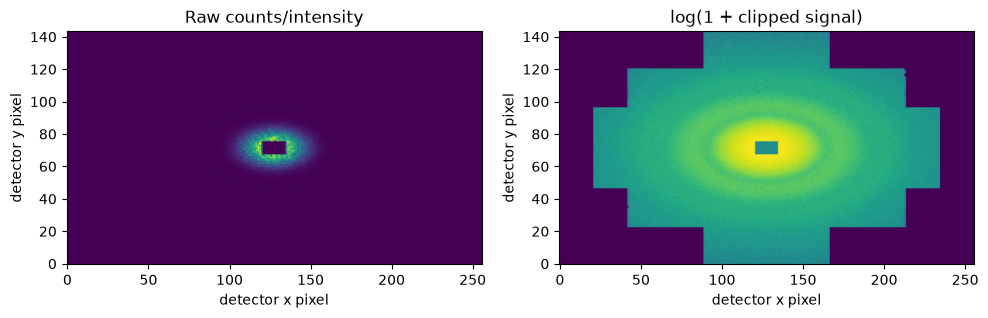

In [ ]:
def find_2d_signal(entry):
    candidates = []
    for name, group in entry['data'].items():
        if isinstance(group, h5py.Group) and 'data' in group and group['data'].ndim == 2:
            candidates.append(f'data/{name}/data')
    if len(candidates) != 1:
        raise ValueError(f'Expected one 2-D detector signal, found {candidates}')
    return candidates[0]

with h5py.File(example_path, 'r') as h5:
    entry_names = [name for name in h5 if name.startswith('entry')]
    first = h5[entry_names[0]]
    signal_path = find_2d_signal(first)
    image = np.asarray(first[signal_path], dtype=np.float32)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].imshow(image, origin='lower')
axes[0].set_title('Raw counts/intensity')
axes[1].imshow(np.log1p(np.clip(image, 0, None)), origin='lower')
axes[1].set_title('log(1 + clipped signal)')
for ax in axes: 
    ax.set(xlabel='detector x pixel', ylabel='detector y pixel')
plt.tight_layout()

## Validate before training

A successful simulation process is not automatically a valid ML example. 

Check: expected entry count; identical shapes and units; finite and nonnegative values where appropriate; signal that is not entirely zero; parameter bounds and combinations; duplicated rows; missing or failed jobs; class balance; and plots from random points and parameter-space boundaries. Also verify that train/validation/test splitting cannot put correlated replicates into different sets.

In [124]:
def validate_nexus(path):
    issues, shapes = [], set()
    with h5py.File(path, 'r') as h5:
        names = [name for name in h5 if name.startswith('entry')]
        if not names:
            return {'file': str(path), 'entries': 0, 'shapes': [], 'issues': ['no entries']}
        for name in names:
            entry = h5[name]
            try:
                signal_path = find_2d_signal(entry)
                image = np.asarray(entry[signal_path])
                shapes.add(image.shape)
                if not np.isfinite(image).all(): 
                    issues.append(f'{name}: non-finite values')
                if np.nanmax(image) <= 0: 
                    issues.append(f'{name}: no positive signal')
            except Exception as exc:
                issues.append(f'{name}: {exc}')
        if len(shapes) > 1:
            issues.append(f'inconsistent detector shapes: {sorted(shapes)}')
    return {'file': str(path), 'entries': len(names), 'shapes': sorted(shapes), 'issues': issues}

h5_files = list((ROOT / 'generated_dataset').rglob('mccode.h5'))
reports = [validate_nexus(path) for path in h5_files]
errors = 0
for report in reports:
    status = 'OK' if not report['issues'] else f'{len(report["issues"])} issue(s)'
    if status != 'OK':
        print(f'Issues found in {report["file"]}: {report["issues"]}')
        errors += 1
        
if errors > 0:
    print(f"Done. Found issues in {errors} out of {len(reports)} files.")
else:
    print("Done. All files validated successfully.")

Done. All files validated successfully.


In [107]:
image_only_gib = image.nbytes / 1000**2
print(f"One detector data array: {image_only_gib:.2f} MB")
print("NeXus also stores errors, event counts, other monitors, and metadata. \nHaving many hdf5 files is likely to increase the total storage footprint significantly.")
!du -hs generated_dataset/core_shell_000000/mccode.h5

One detector data array: 0.15 MB
NeXus also stores errors, event counts, other monitors, and metadata. 
Having many hdf5 files is likely to increase the total storage footprint significantly.
2.2M	generated_dataset/core_shell_000000/mccode.h5


## Connect parameter variation to later training

Choosing parameters is part of defining the learning problem, not only part of running the simulator. This will define the variance within the dataset, and therefore what is learnable from it.

### Sample variation and instrument variation carry different information

A detector image is produced jointly by a sample set inside an instrument. 

Sample parameters describe the material or structure we usually want to infer, while instrument parameters describe how that structure is illuminated and observed. A useful AI dataset must represent both sources of variability deliberately.

### Information introduced by sample parameters

The sample family—sphere, core–shell, or linear pearls in this example—changes the underlying scattering model and is therefore the classification label in our specific example. Continuous sample parameters change the signal within a class:

- `radius` changes characteristic feature positions and length scales;
- `pd_radius` controls polydispersity and can smooth or broaden features;
- `thickness` changes the relationship between core and shell scattering;
- `edge_sep` changes correlations between pearls and therefore the structure factor.

Varying these parameters adds variance to the generated dataset that may allow to teach a classifier which features remain characteristic of a class despite within-class diversity. 

If the sample space is too narrow, the model may memorize a few ideal patterns. If it is unrealistically broad, different classes may become physically ambiguous. Bounds and distributions therefore need scientific justification.

<img src="https://sastutorials.org/Spheres/Spheres.png" height=100 />
<img src="https://sastutorials.org/CoreShell/CoreShell.png" width=100 />
<img src="https://www.sasview.org/docs/_images/linear_pearls_geometry.jpg" height=100 />

### Information introduced by instrument parameters

Instrument parameters do not normally change the sample itself. They change the measurement transfer function, resolution, accessible range, intensity, noise, and detector representation. Examples include wavelength, wavelength spread, collimation, slit setting, sample-to-detector distance, pixel size, beam center, flux, background, and neutron count.

Instrument variation teaches the model that the same sample can produce different measured images under different configurations. This is essential when deployment data will come from several configurations or beamlines. Without it, a model may perform well only at the single simulated setting. However, adding instrument variability can make the learning problem harder because sample information may be blurred, shifted, cropped, or hidden by noise.

Some instrument values may be supplied to the network as metadata when they are known during inference. Others may be treated as nuisance variables: they are varied during training but hidden from the network so it must learn invariance. This decision must match the intended deployment workflow.

<img src="https://mlz-garching.de/index.php?rex_media_type=content_noresize&rex_media_file=kws-2_schema_2024_beide-wans.jpg" height=400>

### Cross sample and instrument variation to avoid confounding

The most dangerous dataset design is one where sample class and instrument configuration are correlated. For example, if every sphere is simulated at one wavelength and every core–shell sample at another, a classifier can achieve high accuracy by identifying wavelength-dependent detector features without learning the sample physics. This shortcut fails as soon as configurations change.

For classification, each sample family should therefore experience the same distribution of relevant instrument configurations. 

A fully crossed design evaluates every sample design under every instrument configuration; this gives excellent separation of effects but can be expensive. A matched design is cheaper: corresponding rows from every class receive the same configuration distribution. Random independent assignment is acceptable only when the dataset is large enough and balance is verified explicitly.

### splitting and evaluation

Store sample parameters, instrument parameters, seeds, and replicate-group identifiers separately in the manifest. This makes it possible to build splits later, audit accidental correlations, condition the model on selected metadata, and report performance as a function of both sample and instrument configuration rather than as one average accuracy.

The KWS sample instruments expose `SlitSetting` and `Lam`. The next cell assigns the same configuration distribution to every sample family: rows with the same numeric index receive identical wavelength and slit settings in all three classes. This prevents these settings from becoming an accidental classification shortcut.

In [108]:
configuration_rng = np.random.default_rng(31415)
matched_configurations = [
    {
        'Lam': float(configuration_rng.uniform(4.0, 10.0)),
        'SlitSetting': int(configuration_rng.choice([1, 2, 3])),
    }
    for _ in range(max(class_counts.values()))
]

design_with_instrument_variation = []
for row in design:
    row_index = int(row['simulation_id'].rsplit('_', 1)[1])
    design_with_instrument_variation.append({
        **row,
        **matched_configurations[row_index],
    })

for family in ('sphere', 'core_shell', 'linear_pearls'):
    family_rows = [r for r in design_with_instrument_variation if r['sample_family'] == family]
    slit_counts = {setting: sum(r['SlitSetting'] == setting for r in family_rows) for setting in (1, 2, 3)}
    print(f'{family:14s}: {len(family_rows)} rows, slit counts {slit_counts}')

design_with_instrument_variation[:3]

sphere        : 334 rows, slit counts {1: 113, 2: 113, 3: 108}
core_shell    : 333 rows, slit counts {1: 113, 2: 112, 3: 108}
linear_pearls : 333 rows, slit counts {1: 113, 2: 112, 3: 108}


[{'simulation_id': 'sphere_000000',
  'sample_family': 'sphere',
  'instrument': 'kws_sphere.instr',
  'radius': 22.99504178332324,
  'pd_radius': 0.05136560525755927,
  'Lam': 6.998135977169644,
  'SlitSetting': 1},
 {'simulation_id': 'sphere_000001',
  'sample_family': 'sphere',
  'instrument': 'kws_sphere.instr',
  'radius': 28.900377806011903,
  'pd_radius': 0.028533722146988218,
  'Lam': 9.173063351576921,
  'SlitSetting': 1},
 {'simulation_id': 'sphere_000002',
  'sample_family': 'sphere',
  'instrument': 'kws_sphere.instr',
  'radius': 62.78899412781471,
  'pd_radius': 0.05389951426597703,
  'Lam': 9.024404117281314,
  'SlitSetting': 1}]

### Generate scripts for the sample-and-instrument design

The original scripts above intentionally use only the sample parameters. The following cells turn `design_with_instrument_variation` into a second manifest and three new shell scripts. Every simulation command now passes both `Lam` and `SlitSetting`, in addition to its class-specific sample parameters. Results go into `generated_dataset_with_instrument_variation/` so they cannot be confused with or overwrite the sample-only dataset.


In [111]:
INSTRUMENT_PARAMETER_BOUNDS = {
    'Lam': (4.0, 10.0),
    'SlitSetting': (1, 3),
}
INSTRUMENT_VARIATION_OUTPUT_ROOT = 'generated_dataset_with_instrument_variation'

def make_instrument_variation_command(
    row, histories=10_000_000, backend=BACKEND, mpi=MPI_RANKS,
    output_root=INSTRUMENT_VARIATION_OUTPUT_ROOT,
):
    command = make_simulation_command(
        row, histories=histories, backend=backend, mpi=mpi,
        output_root=output_root,
    )
    instrument_source = (ROOT / row['instrument']).read_text()
    for name, (lower, upper) in INSTRUMENT_PARAMETER_BOUNDS.items():
        if name not in instrument_source:
            raise ValueError(f'{name!r} was not found in {row["instrument"]}')
        if name not in row:
            raise ValueError(f'{name!r} is missing from {row["simulation_id"]}')
        if not lower <= row[name] <= upper:
            raise ValueError(f'{name}={row[name]} is outside [{lower}, {upper}]')
        command.append(f'{name}={row[name]:.12g}')
    return command

instrument_variation_commands = [
    make_instrument_variation_command(
        row, histories=histories, backend=BACKEND, mpi=MPI_RANKS
    )
    for row in design_with_instrument_variation
]

print(f'Generated {len(instrument_variation_commands):,} commands with instrument variation')
for row, command in list(zip(design_with_instrument_variation, instrument_variation_commands))[:3]:
    print(f'{row["simulation_id"]}:\n  {shlex.join(command)}\n')


Generated 1,000 commands with instrument variation
sphere_000000:
  mpirun -np 6 ./kws_sphere.out --ncount=10000000 --dir=generated_dataset_with_instrument_variation/sphere_000000 --format=NeXus --bufsiz=10000000 radius=22.9950417833 pd_radius=0.0513656052576 Lam=6.99813597717 SlitSetting=1

sphere_000001:
  mpirun -np 6 ./kws_sphere.out --ncount=10000000 --dir=generated_dataset_with_instrument_variation/sphere_000001 --format=NeXus --bufsiz=10000000 radius=28.900377806 pd_radius=0.028533722147 Lam=9.17306335158 SlitSetting=1

sphere_000002:
  mpirun -np 6 ./kws_sphere.out --ncount=10000000 --dir=generated_dataset_with_instrument_variation/sphere_000002 --format=NeXus --bufsiz=10000000 radius=62.7889941278 pd_radius=0.053899514266 Lam=9.02440411728 SlitSetting=1



In [112]:
def instrument_variation_shell_script(family, commands):
    instrument = class_specs[family]['instrument']
    compile_command = make_compile_command(instrument, backend=BACKEND, mpi=MPI_RANKS)
    lines = [
        SLURM_HEADER.rstrip(),
        'set -euo pipefail',
        '',
        '# Generated from design_with_instrument_variation.',
        '# Every run varies Lam and SlitSetting as well as the sample parameters.',
        f'mkdir -p {INSTRUMENT_VARIATION_OUTPUT_ROOT}',
        shlex.join(compile_command),
        '',
    ]
    lines.extend(shlex.join(command) for command in commands)
    return '\n'.join(lines) + '\n'

instrument_variation_scripts = {}
for family in class_specs:
    family_commands = [
        command
        for row, command in zip(design_with_instrument_variation, instrument_variation_commands)
        if row['sample_family'] == family
    ]
    filename = f'run_instrument_variation_{family}.sh'
    instrument_variation_scripts[filename] = instrument_variation_shell_script(
        family, family_commands
    )
    print(f'{filename}: {len(family_commands)} simulation commands')


run_instrument_variation_sphere.sh: 334 simulation commands
run_instrument_variation_core_shell.sh: 333 simulation commands
run_instrument_variation_linear_pearls.sh: 333 simulation commands


The next cell writes `simulation_manifest_with_instrument_variation.json` and the three executable scripts `run_instrument_variation_sphere.sh`, `run_instrument_variation_core_shell.sh`, and `run_instrument_variation_linear_pearls.sh`. Set `WRITE_INSTRUMENT_VARIATION_SCRIPTS=False` for a dry run.


In [113]:
WRITE_INSTRUMENT_VARIATION_SCRIPTS = True
OVERWRITE_INSTRUMENT_VARIATION_SCRIPTS = True

if WRITE_INSTRUMENT_VARIATION_SCRIPTS:
    varied_manifest_path = ROOT / 'simulation_manifest_with_instrument_variation.json'
    if varied_manifest_path.exists() and not OVERWRITE_INSTRUMENT_VARIATION_SCRIPTS:
        print(f'Skipped existing {varied_manifest_path.name}')
    else:
        varied_manifest_path.write_text(
            json.dumps(design_with_instrument_variation, indent=2) + '\n'
        )
        print(
            f'Wrote {varied_manifest_path.name} with '
            f'{len(design_with_instrument_variation):,} rows'
        )

    for filename, content in instrument_variation_scripts.items():
        destination = ROOT / filename
        if destination.exists() and not OVERWRITE_INSTRUMENT_VARIATION_SCRIPTS:
            print(f'Skipped existing {destination.name}')
            continue
        destination.write_text(content)
        destination.chmod(destination.stat().st_mode | 0o111)
        print(f'Wrote executable {destination.name}')
else:
    print('Dry run only. Set WRITE_INSTRUMENT_VARIATION_SCRIPTS=True to create the files.')


Wrote simulation_manifest_with_instrument_variation.json with 1,000 rows
Wrote executable run_instrument_variation_sphere.sh
Wrote executable run_instrument_variation_core_shell.sh
Wrote executable run_instrument_variation_linear_pearls.sh


## Validate parameter bounds and detect duplicate simulations

Detector validation alone cannot detect a corrupted or accidentally repeated design. The enhanced validator below checks stored simulation parameters against expected bounds and constructs a parameter signature for every entry. Identical signatures indicate duplicate parameter combinations. Repeated combinations are acceptable when they intentionally use different random seeds to measure Monte Carlo variation; in that case include the seed in the signature or record a shared replicate group.

In [123]:
PARAMETER_BOUNDS = {
    'radius': (10.0, 100.0),
    'pd_radius': (0.0, 0.1),
    'thickness': (10.0, 100.0),
    'edge_sep': (100.0, 400.0),
}

def validate_nexus_parameters(path, parameter_bounds):
    issues = []
    signatures = {}
    checked = 0
    with h5py.File(path, 'r') as h5:
        entry_names = [name for name in h5 if name.startswith('entry')]
        for entry_name in entry_names:
            checked += 1
            params = h5[f'{entry_name}/simulation/Param']
            signature = []
            for parameter, (lower, upper) in parameter_bounds.items():
                if parameter not in params:
                    continue  # class-specific parameters need not exist in every file
                value = float(params[parameter].asstr()[0])
                signature.append((parameter, value))
                if not lower <= value <= upper:
                    issues.append(
                        f'{entry_name}: {parameter}={value:g} is outside [{lower:g}, {upper:g}]'
                    )
            signature = tuple(signature)
            if signature and signature in signatures:
                issues.append(
                    f'{entry_name}: duplicates parameters from {signatures[signature]}: {signature}'
                )
            elif signature:
                signatures[signature] = entry_name
    return {
        'file': str(path),
        'entries_checked': checked,
        'issues': issues,
    }

h5_files = list((ROOT / 'generated_dataset_with_instrument_variation').rglob('mccode.h5'))
parameter_reports = [validate_nexus_parameters(path, PARAMETER_BOUNDS) for path in h5_files]
for report in parameter_reports:
    status = 'OK' if not report['issues'] else f'{len(report["issues"])} issue(s)'
    print(f'{Path(report["file"]).parent.name:45s} {status}')

# Inspect details rather than silently discarding duplicates.
example_issues = next((r['issues'] for r in parameter_reports if r['issues']), [])
example_issues[:5]

linear_pearls_000105                          OK
sphere_000287                                 OK
core_shell_000239                             OK
sphere_000041                                 OK
sphere_000273                                 OK
core_shell_000206                             OK
core_shell_000034                             OK
linear_pearls_000308                          OK
sphere_000274                                 OK
sphere_000046                                 OK
sphere_000280                                 OK
linear_pearls_000102                          OK
linear_pearls_000330                          OK
sphere_000079                                 OK
core_shell_000033                             OK
core_shell_000201                             OK
sphere_000242                                 OK
sphere_000070                                 OK
linear_pearls_000134                          OK
linear_pearls_000306                          OK
core_shell_000208   

[]

## Design interpolation and extrapolation evaluations

A random stratified split mainly measures interpolation: training and test examples occupy the same parameter ranges. An extrapolation split asks a harder and different question by reserving boundary regions that training never sees. Both are useful and can be reported separately.

The functions below operate on the balanced manifest. The interpolation alternative shuffles within each class and assigns the same proportions to every class. The extrapolation alternative reserves small and large radii for testing, uses only central radii for training and validation, and therefore measures generalization beyond the training support.

In [122]:
def interpolation_split(rows, seed=123, train_fraction=0.70, validation_fraction=0.15):
    split_rng = np.random.default_rng(seed)
    result = {'train': [], 'validation': [], 'test_interpolation': []}
    for family in sorted({row['sample_family'] for row in rows}):
        family_rows = [row for row in rows if row['sample_family'] == family]
        order = split_rng.permutation(len(family_rows))
        train_end = int(train_fraction * len(order))
        validation_end = train_end + int(validation_fraction * len(order))
        result['train'].extend(family_rows[i] for i in order[:train_end])
        result['validation'].extend(family_rows[i] for i in order[train_end:validation_end])
        result['test_interpolation'].extend(family_rows[i] for i in order[validation_end:])
    return result

def extrapolation_split(rows, lower_test_edge=20.0, upper_test_edge=90.0, seed=123):
    split_rng = np.random.default_rng(seed)
    result = {'train': [], 'validation': [], 'test_extrapolation': []}
    for family in sorted({row['sample_family'] for row in rows}):
        family_rows = [row for row in rows if row['sample_family'] == family]
        boundary = [row for row in family_rows if row['radius'] < lower_test_edge or row['radius'] > upper_test_edge]
        interior = [row for row in family_rows if lower_test_edge <= row['radius'] <= upper_test_edge]
        split_rng.shuffle(interior)
        validation_count = max(1, int(0.15 * len(interior)))
        result['validation'].extend(interior[:validation_count])
        result['train'].extend(interior[validation_count:])
        result['test_extrapolation'].extend(boundary)
    return result

interpolation = interpolation_split(design_with_instrument_variation)
extrapolation = extrapolation_split(design_with_instrument_variation)
for name, rows in interpolation.items():
    counts = {family: sum(r['sample_family'] == family for r in rows) for family in class_specs}
    print(f'interpolation/{name:18s}: {len(rows):4d} {counts}')
for name, rows in extrapolation.items():
    counts = {family: sum(r['sample_family'] == family for r in rows) for family in class_specs}
    print(f'extrapolation/{name:18s}: {len(rows):4d} {counts}')

interpolation/train             :  699 {'sphere': 233, 'core_shell': 233, 'linear_pearls': 233}
interpolation/validation        :  148 {'sphere': 50, 'core_shell': 49, 'linear_pearls': 49}
interpolation/test_interpolation:  153 {'sphere': 51, 'core_shell': 51, 'linear_pearls': 51}
extrapolation/train             :  663 {'sphere': 221, 'core_shell': 221, 'linear_pearls': 221}
extrapolation/validation        :  115 {'sphere': 39, 'core_shell': 38, 'linear_pearls': 38}
extrapolation/test_extrapolation:  222 {'sphere': 74, 'core_shell': 74, 'linear_pearls': 74}


## Exercise for the day

First think, together with your group, on the scientific purpose of the problem you decide to approach. 

Then start the planning and generation using McStas or McXtrace of a large simulation dataset towards your goal. You may (but it is not strictly necessary) use the provided HPC resources.

Take note on your reasoning, and include this towards the challenge on Friday (the AI task, inputs, targets, nuisance variables, parameter bounds, sampling design, etc.).

Begin with a small smoke test, benchmark representative simulations, estimate CPU-hours and storage, and only then submit the full campaign. 

I recommend to preserve the instrument source, manifest, seeds, environment information, SLURM scripts, logs, validation reports, and dataset version so another student/person can reproduce the result.